# TP1: Signal procesing
## Autor: Volodya ALEKSANYAN

## Data

A guitar note is not a pure sine: it has a fundamental frequency plus harmonics. We want the fundamental, which is the pitch we hear.

## Plan

1. Load each `.wav` file.
2. Plot the waveform.
3. Compute the FFT magnitude spectrum.
4. Find the fundamental frequency and match it to the closest guitar note, with the deviation in cents.

## Setup

In [20]:
import numpy as np
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt

# Theoretical guitar note frequencies (Hz)
NOTE_FREQS = {
    "E1": 329.63,
    "B2": 246.94,
    "G3": 196.00,
    "D4": 146.83,
    "A5": 110.00,
    "E6": 82.41,
}

# "1 cent" value in Hz for each note above (how many Hz a 1-cent deviation represents)
ONE_CENT_HZ = {
    "E1": 0.15,
    "B2": 0.15,
    "G3": 0.15,
    "D4": 0.08,
    "A5": 0.08,
    "E6": 0.04,
}

FILES = ["../data/string_1.wav", "../data/string_2.wav", "../data/string_3.wav"]

## Load the recordings

In [24]:
signals = {}

for f in FILES:
    sr, data = wavfile.read(f)
    data = data.astype(np.float64) / 32768.0
    signals[f] = (sr, data)
    print(f"{f}: sample rate = {sr} Hz, duration = {len(data) / sr:.2f} s")

../data/string_1.wav: sample rate = 44100 Hz, duration = 5.39 s
../data/string_2.wav: sample rate = 22050 Hz, duration = 5.35 s
../data/string_3.wav: sample rate = 22050 Hz, duration = 5.64 s


## Visualize the waveforms

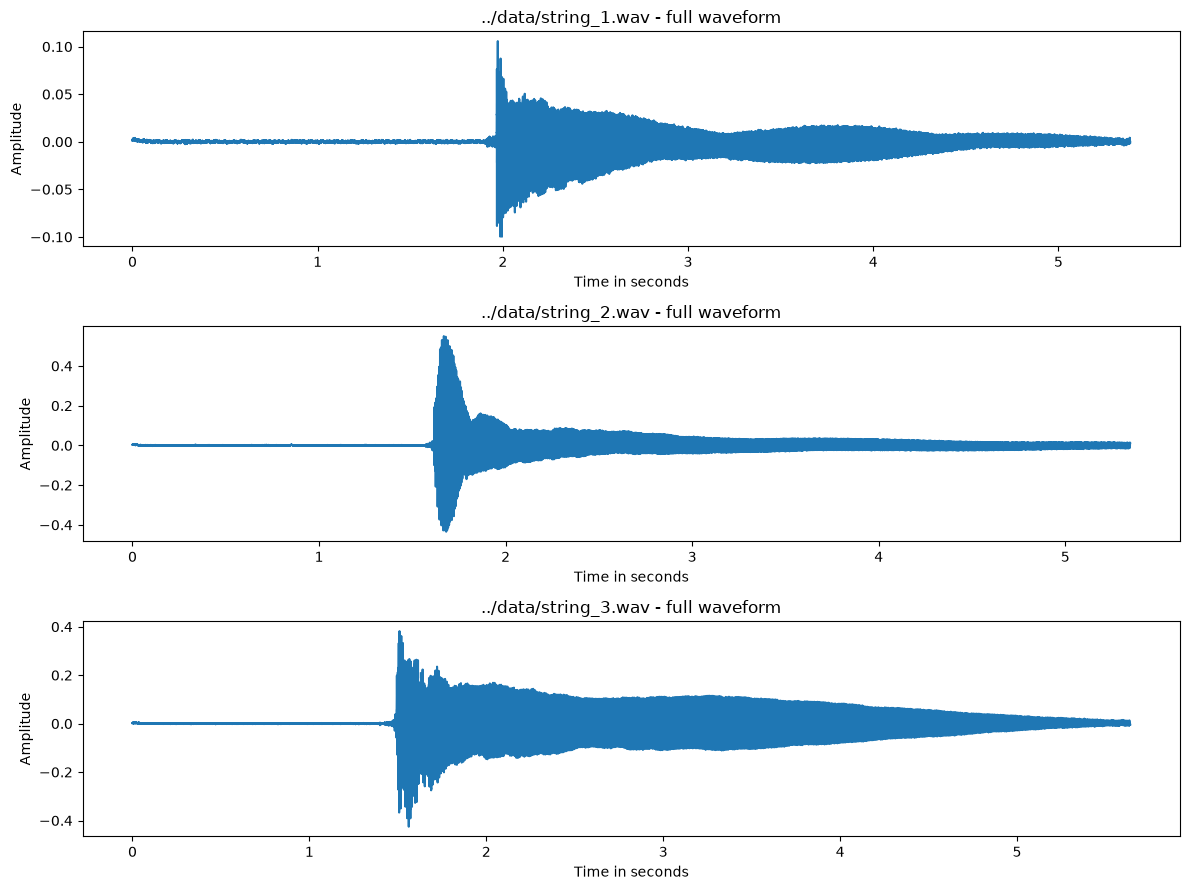

In [25]:
fig, axes = plt.subplots(len(FILES), figsize=(12, 3 * len(FILES)))

for i, f in enumerate(FILES):
    sr, data = signals[f]
    t = np.arange(len(data)) / sr

    axes[i].plot(t, data)
    axes[i].set_title(f"{f} - full waveform")
    axes[i].set_xlabel("Time in seconds")
    axes[i].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Spectral analysis

We skip the first 0.5 s and compute the FFT magnitude spectrum on the next 2 s. fft.fft gives frequencies like [0 ... +max, -max ... 0], thus we use fftshift to reorder them from negative to positive before plotting. We could also just not plot thses as it's redondant... but it's pritier to plot the whole spectrum *:)*

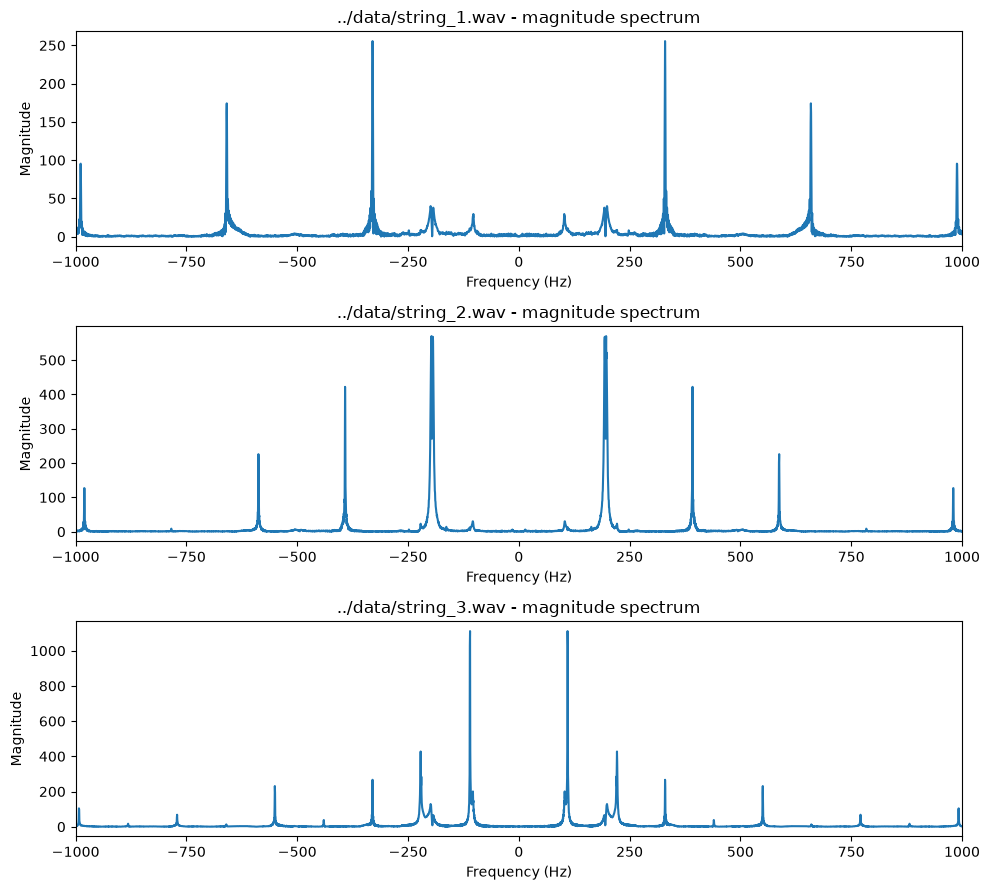

In [26]:
spectra = {}

fig, axes = plt.subplots(len(FILES), 1, figsize=(10, 3 * len(FILES)))

for i, f in enumerate(FILES):
    sr, data = signals[f]

    start = int(sr/2)
    end = min(start + int(2 * sr), len(data))
    segment = data[start:end]

    spectrum = np.abs(fftshift(fft(segment)))
    freqs = fftshift(fftfreq(len(segment), 1 / sr))
    spectra[f] = (freqs, spectrum)

    axes[i].plot(freqs, spectrum)
    axes[i].set_xlim(-1000, 1000)
    axes[i].set_title(f"{f} - magnitude spectrum")
    axes[i].set_xlabel("Frequency (Hz)")
    axes[i].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

## Find the fundamental and the note

Taking the tallest peak can pick a harmonic (for exemple : a string's 2nd or 3rd harmonic can be louder). Since the fundamental is the lowest-frequency peak, we instead take the lowest significant peak (above 20% of the max) and that is actually a "reasonable" choice (in guitar range from 60 to 400HZ).

In [27]:
from scipy.signal import find_peaks


def detect_fundamental(freqs, spectrum, fmin=60, fmax=400):
    guitar_range = (freqs >= fmin) & (freqs <= fmax)
    freqs_r, spec_r = freqs[guitar_range], spectrum[guitar_range]
    df = freqs[1] - freqs[0]
    peaks, _ = find_peaks(spec_r, height=0.2 * spec_r.max(), distance=int(5 / df))
    return freqs_r[peaks[0]], freqs_r[peaks]


def closest_note(freq, note_freqs):
    note, ref_freq = min(note_freqs.items(), key=lambda kv: abs(freq - kv[1]))
    cents = 1200 * np.log2(freq / ref_freq)
    return note, ref_freq, cents


for f in FILES:
    freqs, spectrum = spectra[f]
    f0, all_peaks = detect_fundamental(freqs, spectrum)
    note, ref_freq, cents = closest_note(f0, NOTE_FREQS)
    print(f"{f}: peaks at {np.round(all_peaks, 1)} Hz -> fundamental = {f0:.1f} Hz -> {note} ({cents:+.1f} cents)")

../data/string_1.wav: peaks at [330.] Hz -> fundamental = 330.0 Hz -> E1 (+1.9 cents)
../data/string_2.wav: peaks at [197. 392.] Hz -> fundamental = 197.0 Hz -> G3 (+8.8 cents)
../data/string_3.wav: peaks at [110.  221.5 330. ] Hz -> fundamental = 110.0 Hz -> A5 (+0.0 cents)


## Conclusion

String 1 (E1) and string 2 (G3) are slightly sharp (+1.9 and +8.8 cents). String 3 (A5) seems alright (maybe too perfect ?).